# INT234 Predictive Analytics — Job Market Intelligence
## Phase 3: Exploratory Data Analysis & Statistical Discovery
**Dataset:** Tech Job Postings with Parsed Salaries (ATS Direct), Package `jobs-tier1-L-2026-08-01`  
**Supervised Modeling Cohort:** $N = 34,036$ rows $\times$ 102 columns  
**Author:** Antigravity (Lead Data Scientist & ML Research Engineer)  
**Date:** October 5, 2026  

---

### Scope & Methodological Boundaries
This notebook executes **PHASE 3 ONLY: EXPLORATORY DATA ANALYSIS (EDA) & STATISTICAL DISCOVERY**.
- **In Scope:** Target distribution diagnostics, career seniority profiling, 18-tier role family segmentation, technical skill prevalence, skill-salary association (RQ1), pairwise skill combinations (RQ1), technical skill co-occurrence and Jaccard matrix (RQ2 preparation), geographic and remote work analysis, missingness and outlier diagnostics.
- **Strictly Out of Scope:** PCA, K-Means, any clustering algorithm, predictive regression modeling (Linear, Ridge, Lasso, Random Forest, XGBoost, MLP), hyperparameter tuning, and cluster assignment. Those belong strictly to Phase 4 and Phase 5.


In [1]:
import os
import sys
import json
import itertools
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure UTF-8 output and set deterministic seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting aesthetics
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.titlesize'] = 15
sns.set_theme(style="whitegrid", palette="muted")

print("Environment configured successfully. Random seed fixed at 42.")


Environment configured successfully. Random seed fixed at 42.


## 1. Dataset Ingestion & Selection Funnel Audit
We load the validated Phase 2.1 datasets from `data/processed/`:
1. `cleaned_jobs.parquet`: Full deduplicated ATS corpus ($N = 335,995$).
2. `modeling_dataset.parquet`: Verified supervised modeling cohort ($N = 34,036$).
3. `skill_matrix_technical.parquet`: Dedicated 82-skill technical matrix ($335,995 \times 82$).


In [2]:
base_dir = r"e:\Job Market"
processed_dir = os.path.join(base_dir, "data", "processed")

df_corpus = pd.read_parquet(os.path.join(processed_dir, "cleaned_jobs.parquet"))
df_model = pd.read_parquet(os.path.join(processed_dir, "modeling_dataset.parquet"))
df_tech_skills = pd.read_parquet(os.path.join(processed_dir, "skill_matrix_technical.parquet"))

print(f"Deduplicated Corpus: {len(df_corpus):,} rows x {df_corpus.shape[1]} columns")
print(f"Modeling Cohort:     {len(df_model):,} rows x {df_model.shape[1]} columns")
print(f"Technical Skills:    {df_tech_skills.shape[1]} skills in matrix")


Deduplicated Corpus: 335,995 rows x 24 columns
Modeling Cohort:     34,036 rows x 102 columns
Technical Skills:    82 skills in matrix


In [3]:
# Selection Funnel Quantification (Selection Bias Assessment)
n_raw = 394300
n_dedup = len(df_corpus)
n_tech = int(df_corpus['is_tech_role'].sum())
has_usd_sal = (
    df_corpus['salary_min'].notnull() & df_corpus['salary_max'].notnull() &
    (df_corpus['salary_period'].astype(str).str.lower() == 'year') &
    (df_corpus['salary_currency'] == 'USD') & df_corpus['salary_is_valid']
)
n_disclosed_tech = int((has_usd_sal & df_corpus['is_tech_role']).sum())
n_model = len(df_model)

funnel_table = pd.DataFrame([
    {"Stage": "1. Raw ATS Postings Ingested", "Count": n_raw, "Stage_Retention": 1.0, "Overall_Retention": 1.0},
    {"Stage": "2. Casing Deduplication", "Count": n_dedup, "Stage_Retention": n_dedup / n_raw, "Overall_Retention": n_dedup / n_raw},
    {"Stage": "3. Verified Tech Postings (Corpus)", "Count": n_tech, "Stage_Retention": n_tech / n_dedup, "Overall_Retention": n_tech / n_raw},
    {"Stage": "4. Salary Disclosed (USD Annual)", "Count": n_disclosed_tech, "Stage_Retention": n_disclosed_tech / n_tech, "Overall_Retention": n_disclosed_tech / n_raw},
    {"Stage": "5. Final Modeling Cohort ($30k-$600k)", "Count": n_model, "Stage_Retention": n_model / n_disclosed_tech, "Overall_Retention": n_model / n_raw}
])

display(funnel_table.style.format({
    "Count": "{:,}",
    "Stage_Retention": "{:.2%}",
    "Overall_Retention": "{:.2%}"
}))


,Stage,Count,Stage_Retention,Overall_Retention
0,1. Raw ATS Postings Ingested,"394,300",100.00%,100.00%
1,2. Casing Deduplication,"335,995",85.21%,85.21%
2,3. Verified Tech Postings (Corpus),"114,873",34.19%,29.13%
3,4. Salary Disclosed (USD Annual),"34,121",29.70%,8.65%
4,5. Final Modeling Cohort ($30k-$600k),"34,036",99.75%,8.63%


## 2. Salary Target Distribution & Log Transformation Diagnostics
The target variable is `annual_salary_usd = (salary_min + salary_max) / 2` within the domain-grounded range $[\$30,000, \$600,000]$.

> **Critical Methodological Note:**  
> The logarithmic transformation $\ln(y)$ reduces the right-skew of the salary target from $+0.944$ to $-0.503$.  
> However, **log skewness does NOT prove normal residuals or a normal error structure**. Residual distributions are model-dependent and will be formally tested post-fitting during Phase 5.


In [4]:
sal = df_model['salary_midpoint']
df_model['annual_salary_usd'] = sal
log_sal = np.log1p(sal)

def summarize_var(s, name):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return {
        "Metric": name,
        "N": len(s),
        "Mean": s.mean(),
        "Std": s.std(),
        "Median": s.median(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "Min": s.min(),
        "Max": s.max(),
        "Skewness": s.skew(),
        "Kurtosis": s.kurtosis()
    }

summary_df = pd.DataFrame([
    summarize_var(sal, "Raw Salary Midpoint ($)"),
    summarize_var(df_model['log_salary'], "Natural Log Salary ln(y)"),
    summarize_var(log_sal, "Log1p Salary ln(y+1)")
])

display(summary_df.style.format({
    "N": "{:,}",
    "Mean": "{:,.2f}",
    "Std": "{:,.2f}",
    "Median": "{:,.2f}",
    "Q1": "{:,.2f}",
    "Q3": "{:,.2f}",
    "IQR": "{:,.2f}",
    "Min": "{:,.2f}",
    "Max": "{:,.2f}",
    "Skewness": "{:.3f}",
    "Kurtosis": "{:.3f}"
}))


,Metric,N,Mean,Std,Median,Q1,Q3,IQR,Min,Max,Skewness,Kurtosis
0,Raw Salary Midpoint ($),"34,036","187,020.55","65,817.80","180,372.50","143,870.00","222,000.00","78,130.00","30,000.00","600,000.00",0.944,2.508
1,Natural Log Salary ln(y),"34,036",12.08,0.36,12.10,11.88,12.31,0.43,10.31,13.30,-0.503,0.958
2,Log1p Salary ln(y+1),"34,036",12.08,0.36,12.10,11.88,12.31,0.43,10.31,13.30,-0.503,0.958


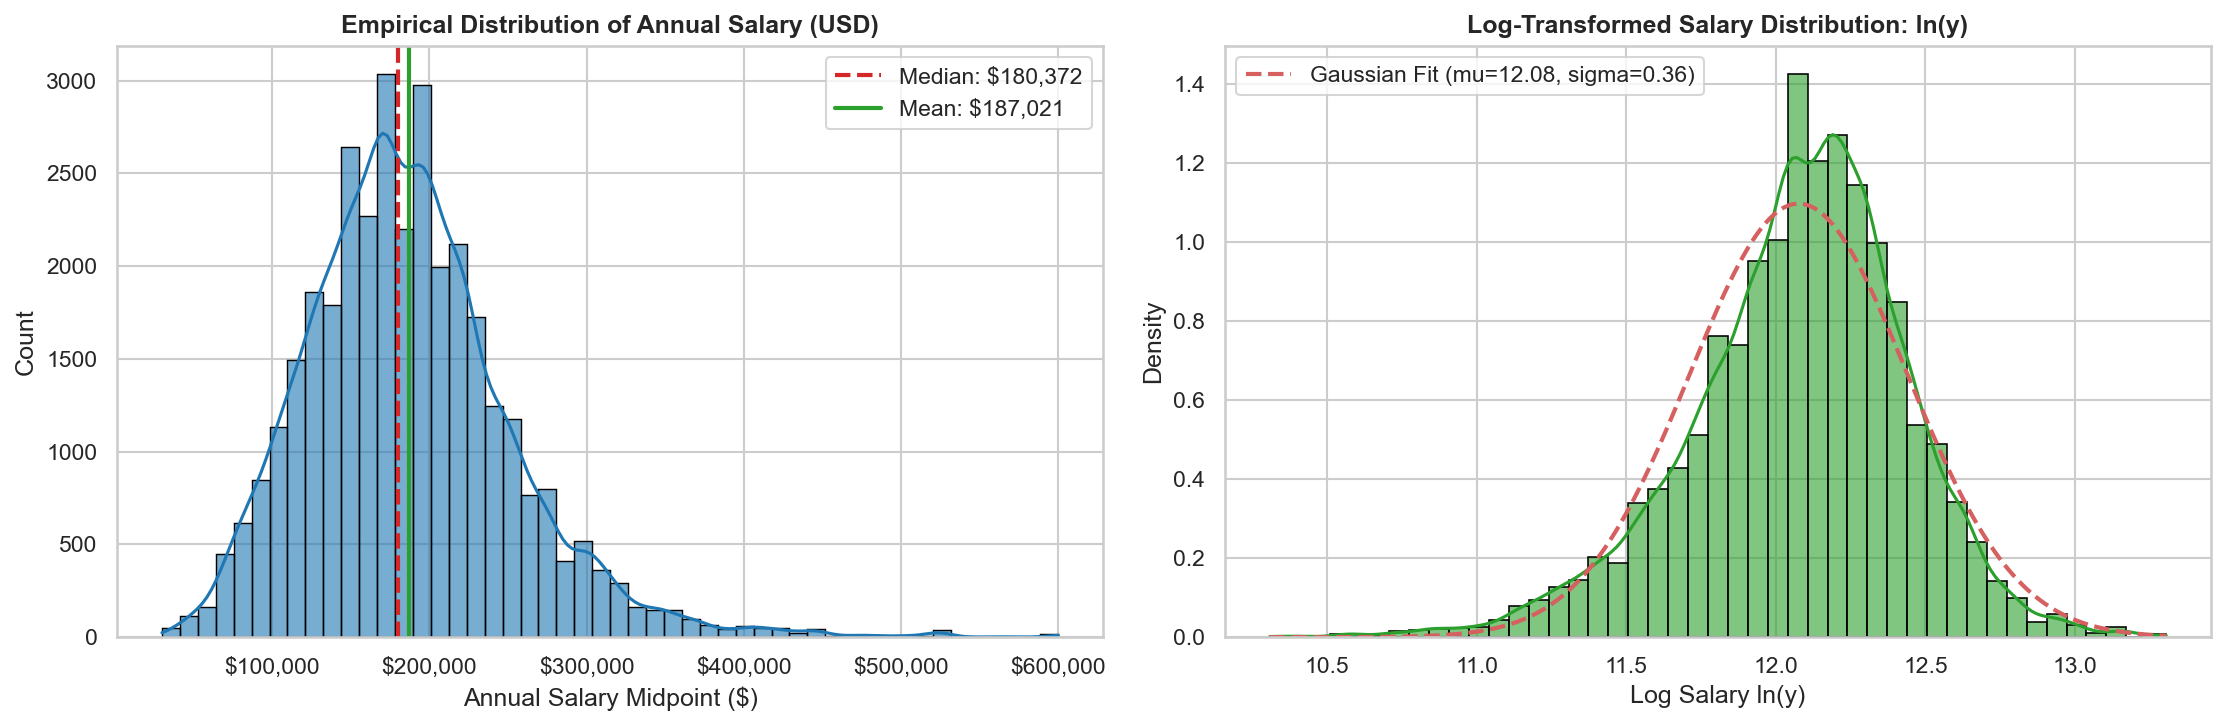

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Raw Salary
sns.histplot(sal, kde=True, bins=50, color='#1f77b4', edgecolor='black', alpha=0.6, ax=axes[0])
axes[0].axvline(sal.median(), color='#d62728', linestyle='--', linewidth=2, label=f'Median: ${sal.median():,.0f}')
axes[0].axvline(sal.mean(), color='#2ca02c', linestyle='-', linewidth=2, label=f'Mean: ${sal.mean():,.0f}')
axes[0].set_title("Empirical Distribution of Annual Salary (USD)", fontweight='bold')
axes[0].set_xlabel("Annual Salary Midpoint ($)")
axes[0].xaxis.set_major_formatter('${x:,.0f}')
axes[0].legend()

# Plot 2: Log Salary with Fitted Gaussian
sns.histplot(df_model['log_salary'], kde=True, bins=45, color='#2ca02c', stat='density', edgecolor='black', alpha=0.6, ax=axes[1])
x_grid = np.linspace(df_model['log_salary'].min(), df_model['log_salary'].max(), 200)
pdf_grid = stats.norm.pdf(x_grid, df_model['log_salary'].mean(), df_model['log_salary'].std())
axes[1].plot(x_grid, pdf_grid, 'r--', linewidth=2, label=f'Gaussian Fit (mu={df_model["log_salary"].mean():.2f}, sigma={df_model["log_salary"].std():.2f})')
axes[1].set_title("Log-Transformed Salary Distribution: ln(y)", fontweight='bold')
axes[1].set_xlabel("Log Salary ln(y)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Career Level / Seniority Segmentation
We analyze compensation across the 5 disambiguated seniority tiers from Phase 2.1:
- `Intern` $\rightarrow$ `Junior / Entry` $\rightarrow$ `Mid / Unspecified` $\rightarrow$ `Senior` $\rightarrow$ `Lead / Principal / Executive`.


,Seniority,N,Share,Median_Salary,Mean_Salary,Std_Dev,IQR
0,Intern,56,0.16%,"$200,000","$182,029","$86,507","$140,000"
1,Junior / Entry,668,1.96%,"$105,000","$110,308","$45,194","$45,000"
2,Mid / Unspecified,"14,210",41.75%,"$155,225","$165,789","$66,071","$75,000"
3,Senior,"8,861",26.03%,"$180,000","$182,219","$43,861","$52,500"
4,Lead / Principal / Executive,"10,241",30.09%,"$220,000","$225,666","$63,087","$73,500"


Kruskal-Wallis across seniority: H = 7,220.05, p = 0.00e+00, epsilon^2 = 0.2120


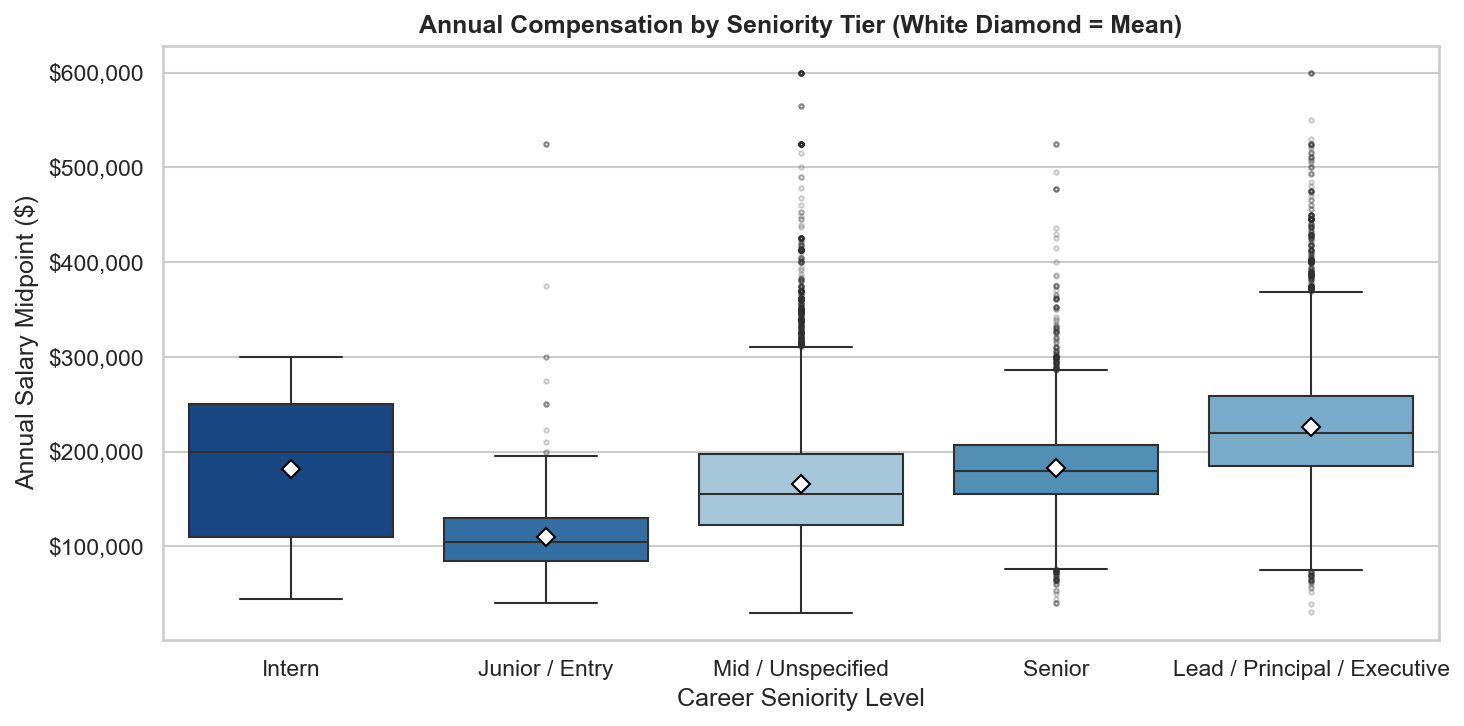

In [6]:
seniority_order = ['Intern', 'Junior / Entry', 'Mid / Unspecified', 'Senior', 'Lead / Principal / Executive']
sen_records = []
sen_groups = []

for sen in seniority_order:
    sub = df_model[df_model['seniority'] == sen]['annual_salary_usd']
    sen_groups.append(sub.values)
    sen_records.append({
        "Seniority": sen,
        "N": len(sub),
        "Share": len(sub) / len(df_model),
        "Median_Salary": sub.median(),
        "Mean_Salary": sub.mean(),
        "Std_Dev": sub.std(),
        "IQR": sub.quantile(0.75) - sub.quantile(0.25)
    })

sen_summary = pd.DataFrame(sen_records)
display(sen_summary.style.format({
    "N": "{:,}",
    "Share": "{:.2%}",
    "Median_Salary": "${:,.0f}",
    "Mean_Salary": "${:,.0f}",
    "Std_Dev": "${:,.0f}",
    "IQR": "${:,.0f}"
}))

# Kruskal-Wallis test
h_sen, p_sen = stats.kruskal(*sen_groups)
eps2_sen = (h_sen - len(seniority_order) + 1) / (len(df_model) - len(seniority_order))
print(f"Kruskal-Wallis across seniority: H = {h_sen:,.2f}, p = {p_sen:.2e}, epsilon^2 = {eps2_sen:.4f}")

# Boxplot
plt.figure(figsize=(10, 5))
palette_sen = ["#9ecae1", "#6baed6", "#4292c6", "#2171b5", "#084594"]
sns.boxplot(data=df_model, x='seniority', y='annual_salary_usd', order=seniority_order,
            hue='seniority', palette=palette_sen, legend=False, showmeans=True,
            meanprops={"marker": "D", "markeredgecolor": "black", "markerfacecolor": "white", "markersize": 6},
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.25})
plt.title("Annual Compensation by Seniority Tier (White Diamond = Mean)", fontweight='bold')
plt.xlabel("Career Seniority Level")
plt.ylabel("Annual Salary Midpoint ($)")
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()


## 4. Role Family Compensation Landscape
We evaluate compensation across the 18 granular role families established in Phase 2.1.
All categories satisfy minimum sample size rules ($N \ge 215 \ge 185$).


,Role_Family,N,Share,Median_Salary,Mean_Salary,Std_Dev,IQR
6,Engineering Management,827,2.43%,"$242,500","$251,224","$60,630","$67,150"
10,Mobile Engineer,309,0.91%,"$200,000","$203,462","$56,553","$59,000"
0,Backend Developer,684,2.01%,"$195,000","$198,646","$51,724","$56,130"
13,Security Engineer,692,2.03%,"$195,000","$201,454","$59,340","$72,500"
17,Technical Product & PM,"2,494",7.33%,"$194,525","$197,844","$50,807","$62,025"
15,Solutions & Architecture,864,2.54%,"$193,500","$194,136","$48,079","$54,500"
14,Software Engineer,"6,511",19.13%,"$192,775","$196,838","$60,369","$70,368"
8,Full-Stack Developer,737,2.17%,"$192,500","$193,753","$49,915","$56,875"
7,Frontend Developer,582,1.71%,"$191,250","$191,035","$63,721","$75,000"
9,ML / AI Engineer,"5,963",17.52%,"$190,000","$199,263","$72,471","$89,000"


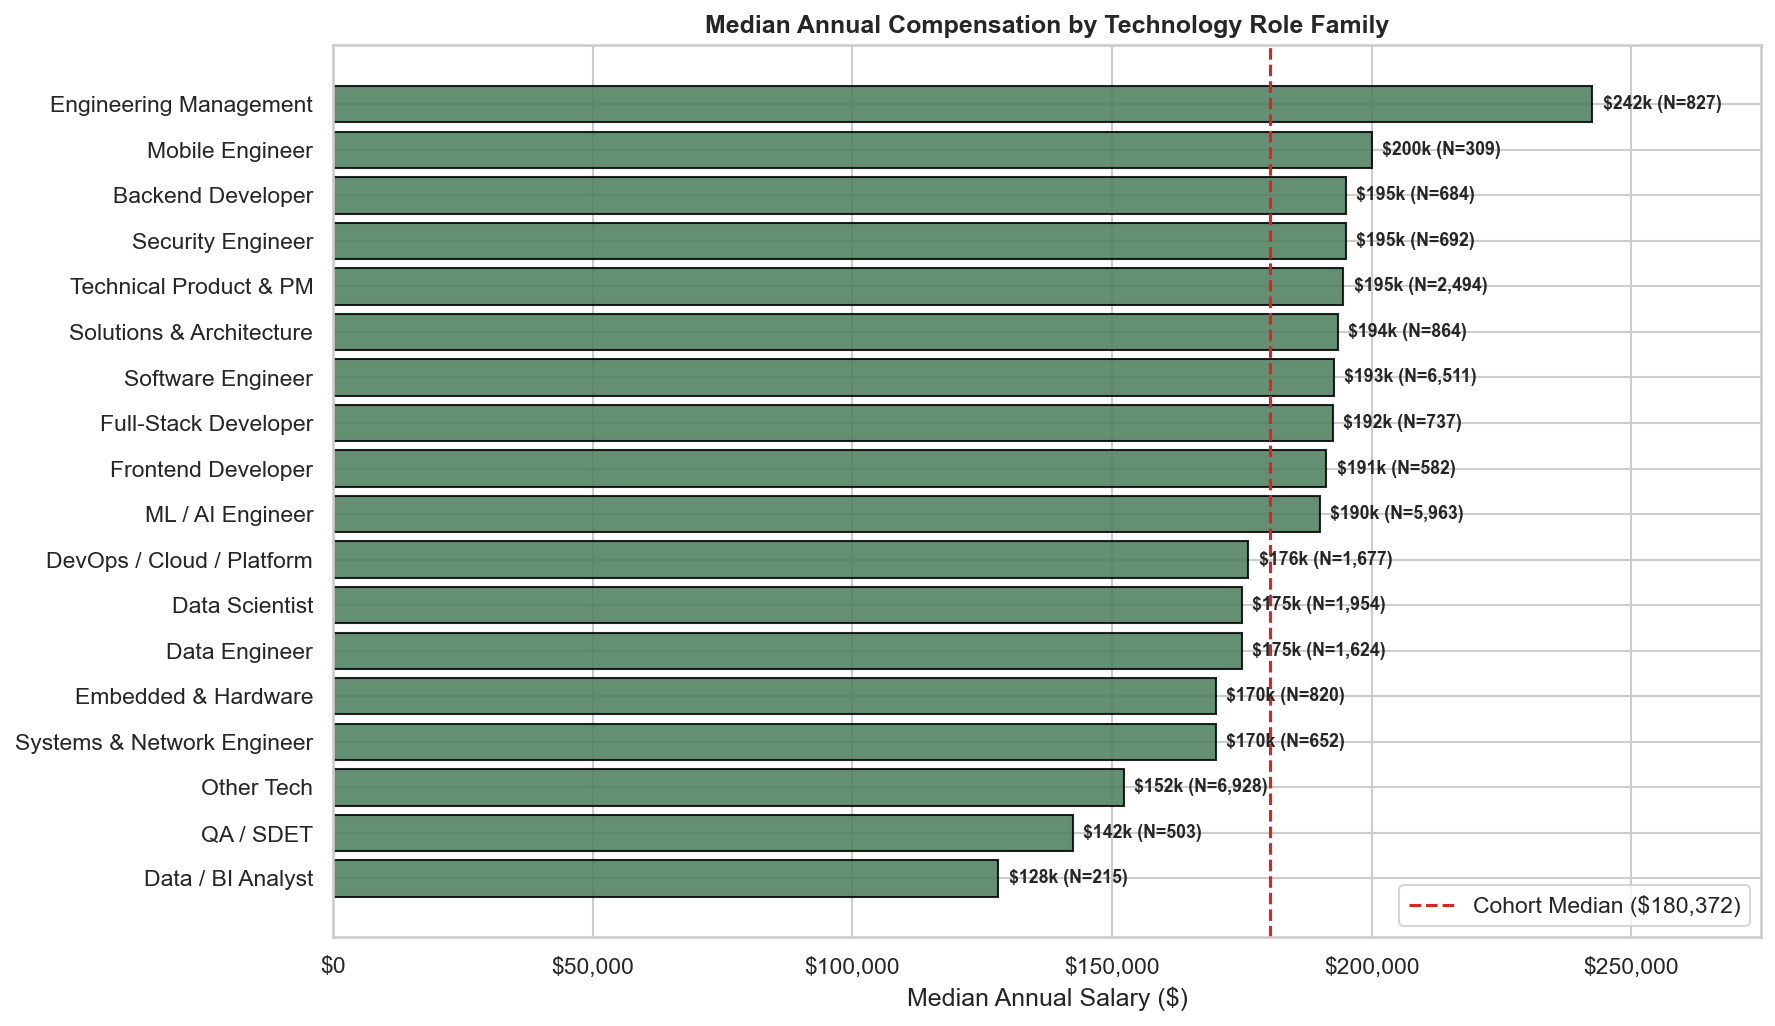

In [7]:
rf_records = []
for rf, sub in df_model.groupby('role_family'):
    s = sub['annual_salary_usd']
    rf_records.append({
        "Role_Family": rf,
        "N": len(s),
        "Share": len(s) / len(df_model),
        "Median_Salary": s.median(),
        "Mean_Salary": s.mean(),
        "Std_Dev": s.std(),
        "IQR": s.quantile(0.75) - s.quantile(0.25)
    })

rf_df = pd.DataFrame(rf_records).sort_values(by="Median_Salary", ascending=False)
display(rf_df.style.format({
    "N": "{:,}",
    "Share": "{:.2%}",
    "Median_Salary": "${:,.0f}",
    "Mean_Salary": "${:,.0f}",
    "Std_Dev": "${:,.0f}",
    "IQR": "${:,.0f}"
}))

# Horizontal bar chart of role family medians
sorted_rf = rf_df.sort_values(by="Median_Salary", ascending=True)
plt.figure(figsize=(12, 7))
y_pos = np.arange(len(sorted_rf))
plt.barh(y_pos, sorted_rf['Median_Salary'], color='#4a7c59', alpha=0.85, edgecolor='black')
plt.yticks(y_pos, sorted_rf['Role_Family'])
plt.axvline(sal.median(), color='#d62728', linestyle='--', linewidth=1.5, label=f'Cohort Median (${sal.median():,.0f})')
plt.xlabel("Median Annual Salary ($)")
plt.title("Median Annual Compensation by Technology Role Family", fontweight='bold')
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.legend(loc='lower right')
plt.xlim(0, 275000)

for i, (med, n_cnt) in enumerate(zip(sorted_rf['Median_Salary'], sorted_rf['N'])):
    plt.text(med + 2000, i, f"${med/1000:.0f}k (N={n_cnt:,})", va='center', fontsize=8.5, fontweight='semibold')

plt.tight_layout()
plt.show()


## 5. Technical Skill Frequency & Prevalence
We evaluate the 82 pure technical skills from `skill_matrix_technical.parquet`.
Prevalence is calculated across both the full corpus ($N = 335,995$) and the modeling cohort ($N = 34,036$).


,Skill,Modeling_Count,Modeling_Prevalence,Corpus_Count,Corpus_Prevalence,IDF_Score
0,airflow,0,0.00%,"2,273",0.68%,10.44
61,redshift,0,0.00%,961,0.29%,10.44
59,react-native,0,0.00%,983,0.29%,10.44
58,react,0,0.00%,"8,544",2.54%,10.44
57,rabbitmq,0,0.00%,867,0.26%,10.44
56,qa-testing,0,0.00%,"9,373",2.79%,10.44
55,pytorch,0,0.00%,"3,028",0.90%,10.44
54,python,0,0.00%,"31,676",9.43%,10.44
53,power-bi,0,0.00%,"5,319",1.58%,10.44
52,php,0,0.00%,844,0.25%,10.44


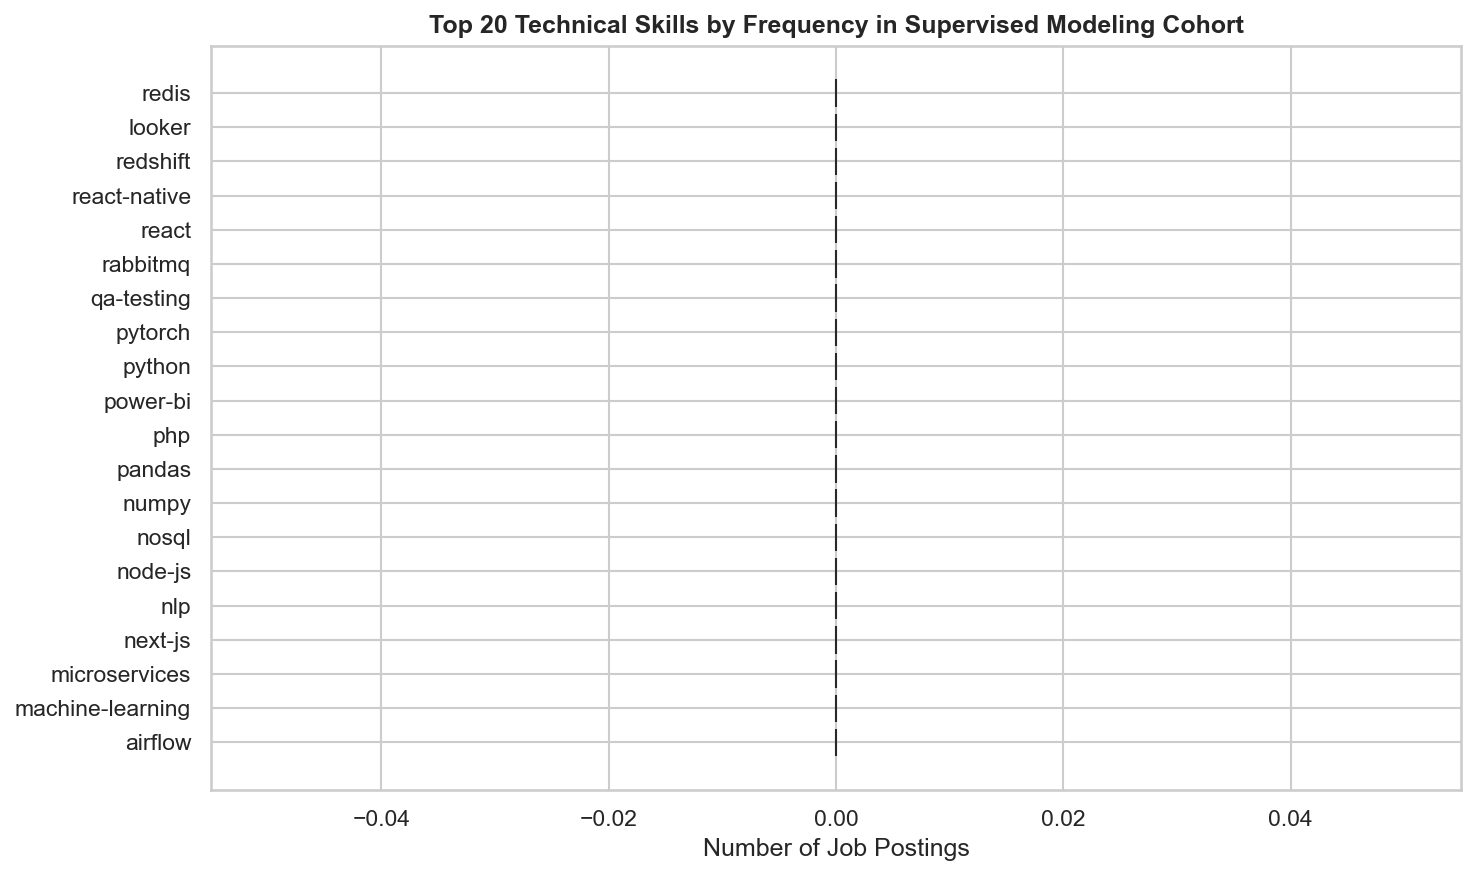

In [8]:
corpus_counts = df_tech_skills.sum()
model_tech_cols = [c for c in df_model.columns if c.startswith('skill_') and c in [f"skill_{s.replace('-', '_').replace('.', '_')}" for s in df_tech_skills.columns]]

skill_records = []
for orig in df_tech_skills.columns:
    mod_col = f"skill_{orig.replace('-', '_').replace('.', '_')}"
    m_count = int(df_model[mod_col].sum()) if mod_col in df_model.columns else 0
    c_count = int(corpus_counts[orig])
    skill_records.append({
        "Skill": orig.replace('skill_', '').replace('_', '-'),
        "Modeling_Count": m_count,
        "Modeling_Prevalence": m_count / len(df_model),
        "Corpus_Count": c_count,
        "Corpus_Prevalence": c_count / len(df_corpus),
        "IDF_Score": np.log(len(df_model) / (m_count + 1))
    })

skill_freq_df = pd.DataFrame(skill_records).sort_values(by="Modeling_Count", ascending=False)
display(skill_freq_df.head(20).style.format({
    "Modeling_Count": "{:,}",
    "Modeling_Prevalence": "{:.2%}",
    "Corpus_Count": "{:,}",
    "Corpus_Prevalence": "{:.2%}",
    "IDF_Score": "{:.2f}"
}))

# Plot top 20 skills
top_20 = skill_freq_df.head(20).sort_values(by="Modeling_Count", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top_20['Skill'], top_20['Modeling_Count'], color='#1f77b4', edgecolor='black', alpha=0.8)
plt.title("Top 20 Technical Skills by Frequency in Supervised Modeling Cohort", fontweight='bold')
plt.xlabel("Number of Job Postings")
plt.tight_layout()
plt.show()


## 6. Skill-Salary Associations & Percentage Premiums (RQ1)
For each technical skill with adequate statistical support ($N \ge 100$), we compute:
- Median and mean salary when the skill is cited.
- Salary premium relative to the cohort median ($180,372.50).
- Non-parametric Mann-Whitney U test with **Benjamini-Hochberg FDR correction**.
- Rank-biserial correlation effect size ($r \in [-1, 1]$).


,Skill,Support_N,Prevalence,Median_Salary,Premium_Dollars,Premium_Percentage,P_Value_Raw,Rank_Biserial_Effect,P_Value_FDR_BH
6,pytorch,"1,088",3.20%,"$220,562","$+40,190",+22.3%,0.000000,-0.406,7.56e-114
46,deep-learning,904,2.66%,"$215,000","$+34,628",+19.2%,0.000000,-0.358,1.63e-74
26,tensorflow,531,1.56%,"$211,000","$+30,628",+17.0%,0.000000,-0.331,1.83e-38
37,scala,497,1.46%,"$209,750","$+29,378",+16.3%,0.000000,-0.220,1.07e-16
17,machine-learning,"6,270",18.42%,"$207,500","$+27,128",+15.0%,0.000000,-0.310,0.00e+00
38,rust,"1,386",4.07%,"$205,502","$+25,130",+13.9%,0.000000,-0.300,3.20e-79
19,redis,593,1.74%,"$204,974","$+24,601",+13.6%,0.000000,-0.229,3.05e-21
43,kotlin,491,1.44%,"$202,000","$+21,628",+12.0%,0.000000,-0.210,3.16e-15
65,kafka,"1,101",3.23%,"$200,000","$+19,628",+10.9%,0.000000,-0.172,7.78e-22
2,react-native,311,0.91%,"$200,000","$+19,628",+10.9%,0.000000,-0.193,8.21e-09


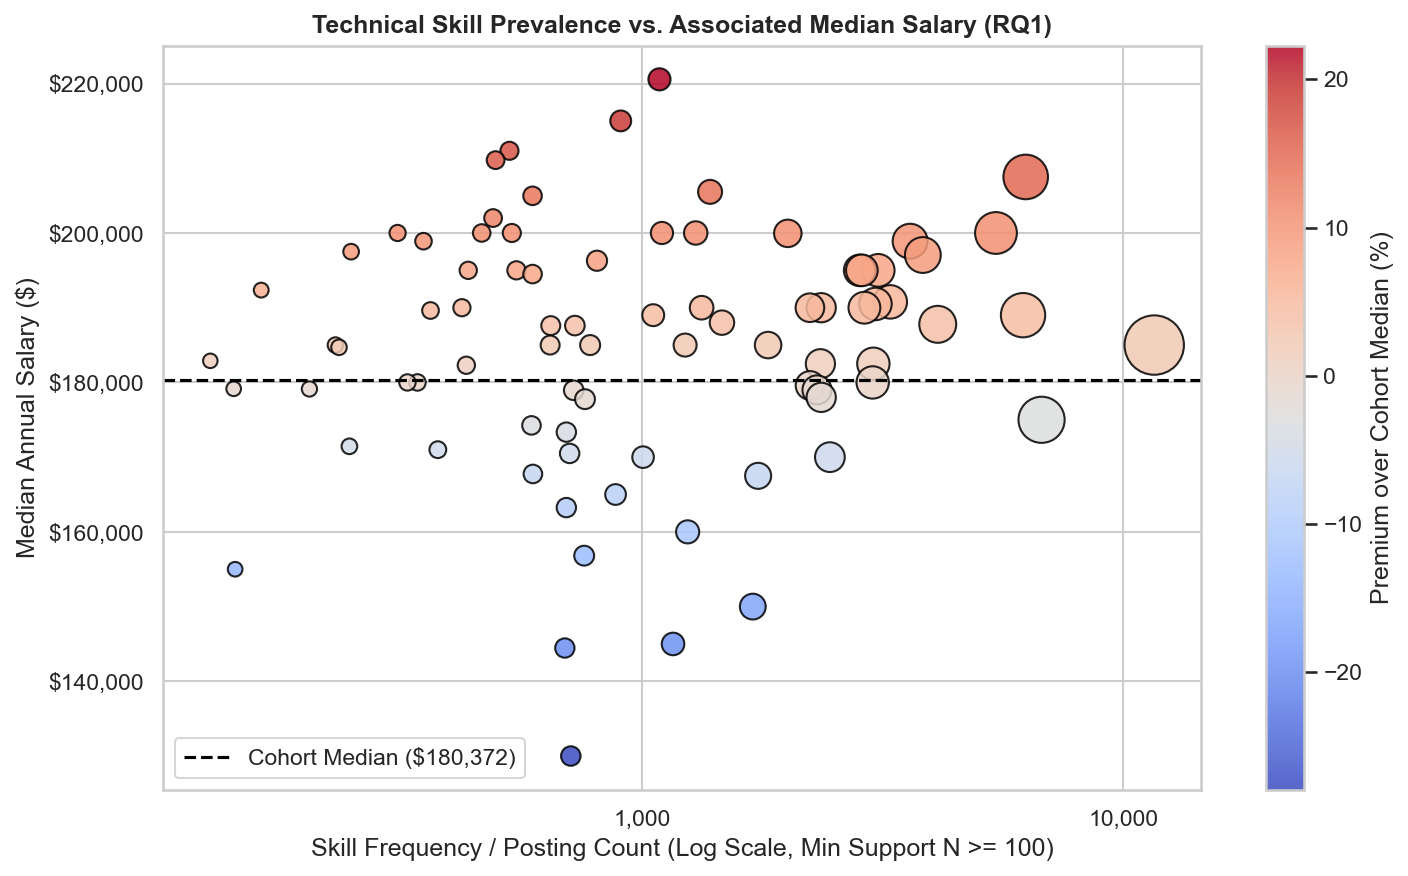

In [9]:
MIN_SUPPORT = 100
cohort_median = float(sal.median())

assoc_records = []
for _, row in skill_freq_df.iterrows():
    s_name = row['Skill']
    m_col = f"skill_{s_name.replace('-', '_').replace('.', '_')}"
    if m_col not in df_model.columns:
        continue
    
    mask = df_model[m_col] == 1
    n_with = int(mask.sum())
    if n_with < MIN_SUPPORT:
        continue
    
    sal_with = df_model.loc[mask, 'annual_salary_usd']
    sal_without = df_model.loc[~mask, 'annual_salary_usd']
    
    med = sal_with.median()
    premium = med - cohort_median
    premium_pct = (premium / cohort_median) * 100.0
    
    u_stat, p_val = stats.mannwhitneyu(sal_with, sal_without, alternative='two-sided')
    rank_biserial = 1.0 - (2.0 * u_stat) / (len(sal_with) * len(sal_without))
    
    assoc_records.append({
        "Skill": s_name,
        "Support_N": n_with,
        "Prevalence": n_with / len(df_model),
        "Median_Salary": med,
        "Premium_Dollars": premium,
        "Premium_Percentage": premium_pct,
        "P_Value_Raw": p_val,
        "Rank_Biserial_Effect": rank_biserial
    })

assoc_df = pd.DataFrame(assoc_records)

# Benjamini-Hochberg correction
m = len(assoc_df)
order = np.argsort(assoc_df['P_Value_Raw'].values)
adj_p = np.zeros(m)
for rank, p in enumerate(assoc_df['P_Value_Raw'].values[order], 1):
    adj_p[rank - 1] = min(p * m / rank, 1.0)
for i in range(m - 2, -1, -1):
    adj_p[i] = min(adj_p[i], adj_p[i + 1])
assoc_df['P_Value_FDR_BH'] = 0.0
assoc_df.loc[order, 'P_Value_FDR_BH'] = adj_p

assoc_df = assoc_df.sort_values(by="Premium_Percentage", ascending=False)
display(assoc_df.head(15).style.format({
    "Support_N": "{:,}",
    "Prevalence": "{:.2%}",
    "Median_Salary": "${:,.0f}",
    "Premium_Dollars": "${:+,.0f}",
    "Premium_Percentage": "{:+.1f}%",
    "P_Value_FDR_BH": "{:.2e}",
    "Rank_Biserial_Effect": "{:.3f}"
}))

# Scatter plot: Prevalence vs Median Salary
plt.figure(figsize=(10, 6))
scatter = plt.scatter(assoc_df['Support_N'], assoc_df['Median_Salary'],
                      c=assoc_df['Premium_Percentage'], cmap='coolwarm',
                      s=assoc_df['Support_N'] / 15 + 40, edgecolors='black', alpha=0.85)
plt.xscale('log')
plt.axhline(cohort_median, color='black', linestyle='--', linewidth=1.5, label=f'Cohort Median (${cohort_median:,.0f})')
plt.title("Technical Skill Prevalence vs. Associated Median Salary (RQ1)", fontweight='bold')
plt.xlabel("Skill Frequency / Posting Count (Log Scale, Min Support N >= 100)")
plt.ylabel("Median Annual Salary ($)")
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.gca().xaxis.set_major_formatter('{x:,.0f}')
plt.colorbar(scatter, label='Premium over Cohort Median (%)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


## 7. Pairwise Skill Combinations & Synergy (RQ1)
RQ1 asks which skill *combinations* are most associated with higher salaries.
We evaluate all pairwise combinations among the top 35 technical skills with support $N \ge 100$.


In [10]:
top_35 = skill_freq_df.head(35)['Skill'].tolist()
skill_med_map = {row['Skill']: row['Median_Salary'] for _, row in assoc_df.iterrows()}

pair_records = []
for s1, s2 in itertools.combinations(top_35, 2):
    col1 = f"skill_{s1.replace('-', '_').replace('.', '_')}"
    col2 = f"skill_{s2.replace('-', '_').replace('.', '_')}"
    if col1 not in df_model.columns or col2 not in df_model.columns:
        continue
    
    both = (df_model[col1] == 1) & (df_model[col2] == 1)
    pair_cnt = int(both.sum())
    if pair_cnt < MIN_SUPPORT:
        continue
    
    p_sal = df_model.loc[both, 'annual_salary_usd']
    p_med = float(p_sal.median())
    prem_cohort = p_med - cohort_median
    max_indiv = max(skill_med_map.get(s1, cohort_median), skill_med_map.get(s2, cohort_median))
    synergy = p_med - max_indiv
    
    pair_records.append({
        "Skill_A": s1,
        "Skill_B": s2,
        "Pair": f"{s1} + {s2}",
        "Co_Occurrence_Count": pair_cnt,
        "Median_Salary": p_med,
        "Premium_vs_Cohort": prem_cohort,
        "Synergy_Premium": synergy
    })

pair_df = pd.DataFrame(pair_records).sort_values(by="Median_Salary", ascending=False)
display(pair_df.head(15).style.format({
    "Co_Occurrence_Count": "{:,}",
    "Median_Salary": "${:,.0f}",
    "Premium_vs_Cohort": "${:+,.0f}",
    "Synergy_Premium": "${:+,.0f}"
}))


,Skill_A,Skill_B,Pair,Co_Occurrence_Count,Median_Salary,Premium_vs_Cohort,Synergy_Premium
44,pytorch,robotics,pytorch + robotics,245,"$235,200","$+54,828","$+14,638"
43,pytorch,machine-learning,pytorch + machine-learning,968,"$222,000","$+41,628","$+1,438"
116,machine-learning,robotics,machine-learning + robotics,854,"$219,188","$+38,815","$+11,688"
48,pytorch,spark,pytorch + spark,152,"$215,000","$+34,628","$-5,562"
40,pytorch,python,pytorch + python,835,"$213,756","$+33,384","$-6,806"
124,machine-learning,spark,machine-learning + spark,714,"$213,375","$+33,002","$+5,875"
45,pytorch,tensorflow,pytorch + tensorflow,497,"$212,500","$+32,128","$-8,062"
146,typescript,snowflake,typescript + snowflake,117,"$211,000","$+30,628","$+16,000"
119,machine-learning,tensorflow,machine-learning + tensorflow,490,"$210,000","$+29,628","$-1,000"
42,pytorch,nlp,pytorch + nlp,139,"$207,675","$+27,302","$-12,888"


## 8. Skill Co-occurrence Structure & Jaccard Heatmap (RQ2 Preparation)
To prepare evidence for RQ2 (*Do job postings naturally form skill-based archetypes?*), we examine the natural clustering of technical skills via the **Jaccard Similarity Matrix**:
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{N_{AB}}{N_A + N_B - N_{AB}}$$

> **Strict Rule:** We do NOT perform PCA or K-Means here. We observe empirical co-occurrence patterns that will motivate Phase 4.


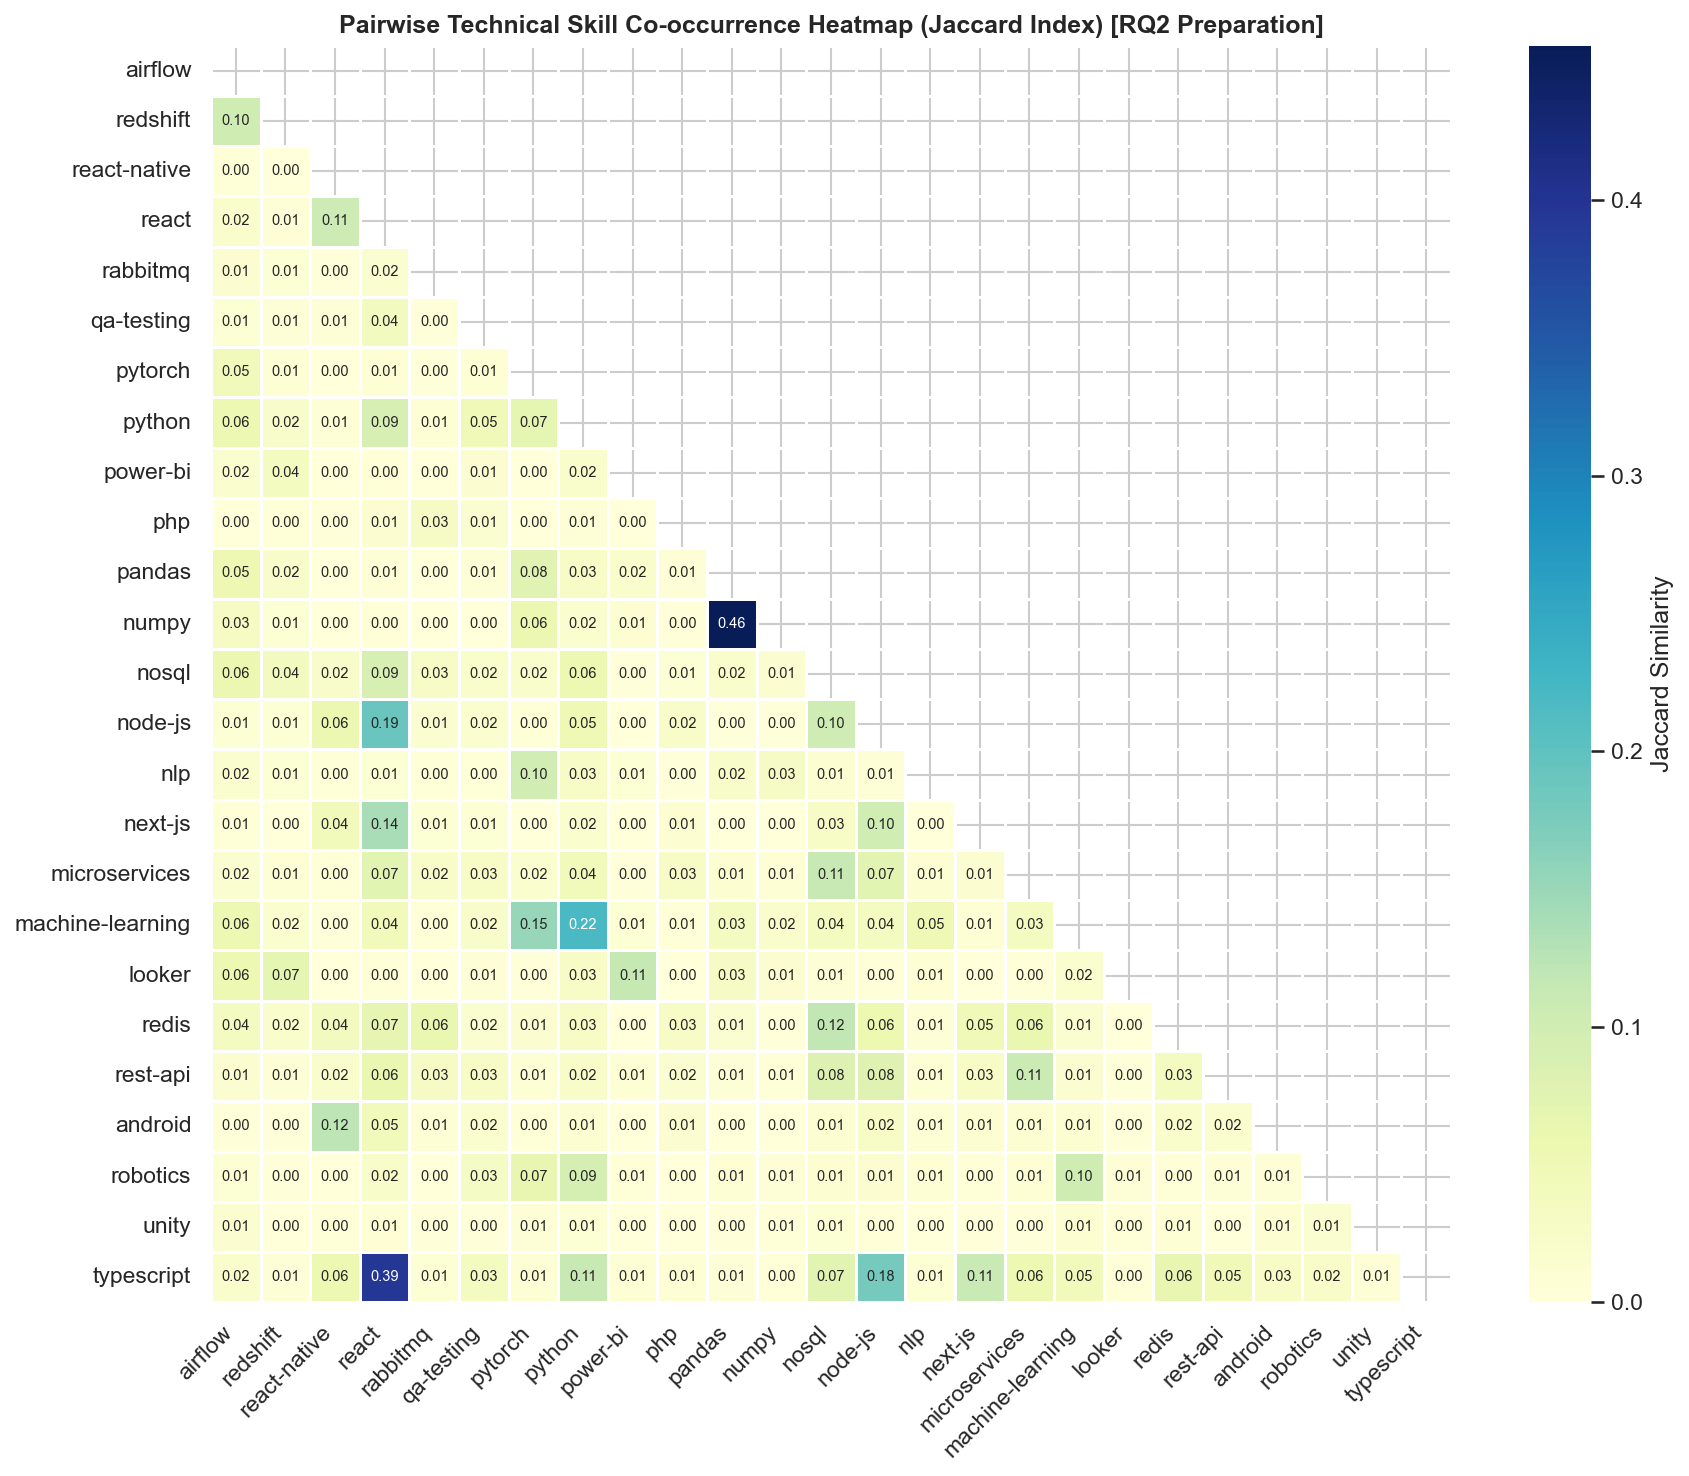

In [11]:
top_25_list = skill_freq_df.head(25)['Skill'].tolist()
top_25_cols = [f"skill_{s.replace('-', '_').replace('.', '_')}" for s in top_25_list]

sub_mat = df_model[top_25_cols].values.astype(np.float64)
cooccur = np.dot(sub_mat.T, sub_mat)
diag = np.diag(cooccur)

jaccard_mat = np.zeros_like(cooccur, dtype=float)
for i in range(len(top_25_list)):
    for j in range(len(top_25_list)):
        u = diag[i] + diag[j] - cooccur[i, j]
        jaccard_mat[i, j] = cooccur[i, j] / u if u > 0 else 0.0

jaccard_df = pd.DataFrame(jaccard_mat, index=top_25_list, columns=top_25_list)

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(jaccard_df, dtype=bool))
sns.heatmap(jaccard_df, mask=mask, cmap='YlGnBu', annot=True, fmt='.2f', annot_kws={"size": 7},
            cbar_kws={'label': 'Jaccard Similarity'}, linewidths=0.5)
plt.title("Pairwise Technical Skill Co-occurrence Heatmap (Jaccard Index) [RQ2 Preparation]", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 9. Geographic & Remote Work Compensation Patterns
We evaluate compensation differences across major tech hubs (`city_clean`) and between remote vs. onsite postings (`is_remote`).


In [12]:
loc_records = []
for city, sub in df_model.groupby('city_clean'):
    s = sub['annual_salary_usd']
    loc_records.append({
        "City": city,
        "N": len(s),
        "Share": len(s) / len(df_model),
        "Median_Salary": s.median(),
        "Mean_Salary": s.mean(),
        "IQR": s.quantile(0.75) - s.quantile(0.25)
    })

loc_df = pd.DataFrame(loc_records).sort_values(by="Median_Salary", ascending=False)
display(loc_df.head(10).style.format({
    "N": "{:,}",
    "Share": "{:.2%}",
    "Median_Salary": "${:,.0f}",
    "Mean_Salary": "${:,.0f}",
    "IQR": "${:,.0f}"
}))

# Remote vs Onsite
sal_remote = df_model.loc[df_model['is_remote'] == True, 'annual_salary_usd']
sal_onsite = df_model.loc[df_model['is_remote'] == False, 'annual_salary_usd']
u_rem, p_rem = stats.mannwhitneyu(sal_remote, sal_onsite, alternative='two-sided')

print(f"Remote Postings: N = {len(sal_remote):,}, Median = ${sal_remote.median():,.0f}, Mean = ${sal_remote.mean():,.0f}")
print(f"Onsite Postings: N = {len(sal_onsite):,}, Median = ${sal_onsite.median():,.0f}, Mean = ${sal_onsite.mean():,.0f}")
print(f"Mann-Whitney U Test: U = {u_rem:,.0f}, p-value = {p_rem:.2e}")


,City,N,Share,Median_Salary,Mean_Salary,IQR
7,Mountain View,610,1.79%,"$220,000","$220,923","$66,125"
11,San Francisco,"4,460",13.10%,"$218,000","$231,038","$86,500"
9,New York City,"1,146",3.37%,"$200,000","$202,511","$72,500"
12,San Jose,412,1.21%,"$200,000","$207,850","$72,750"
13,Seattle,570,1.67%,"$189,950","$192,454","$60,975"
8,New York,"2,311",6.79%,"$178,500","$185,992","$84,026"
10,Other,"19,834",58.27%,"$175,000","$178,852","$79,400"
0,Boston,787,2.31%,"$174,400","$176,717","$66,645"
1,Chicago,507,1.49%,"$170,650","$174,758","$88,753"
2,Costa Mesa,983,2.89%,"$170,000","$184,191","$63,750"


Remote Postings: N = 10,528, Median = $187,500, Mean = $191,484
Onsite Postings: N = 23,508, Median = $177,500, Mean = $185,022
Mann-Whitney U Test: U = 132,778,674, p-value = 4.23e-27


## 10. Missingness Diagnostics & Correlation Analysis
We verify data completeness and compute correlations across strictly valid numeric predictors.


,Field,Corpus_Missing,Corpus_Rate,Modeling_Missing,Modeling_Rate
0,job_id,0,0.00%,0,0.00%
1,title,0,0.00%,0,0.00%
2,company_name,0,0.00%,0,0.00%
3,department,"93,454",27.81%,0,0.00%
4,city,"61,457",18.29%,0,0.00%
5,country,"30,477",9.07%,0,0.00%
6,is_remote,0,0.00%,0,0.00%
7,salary_midpoint,"236,787",70.47%,0,0.00%
8,skills,0,0.00%,0,0.00%


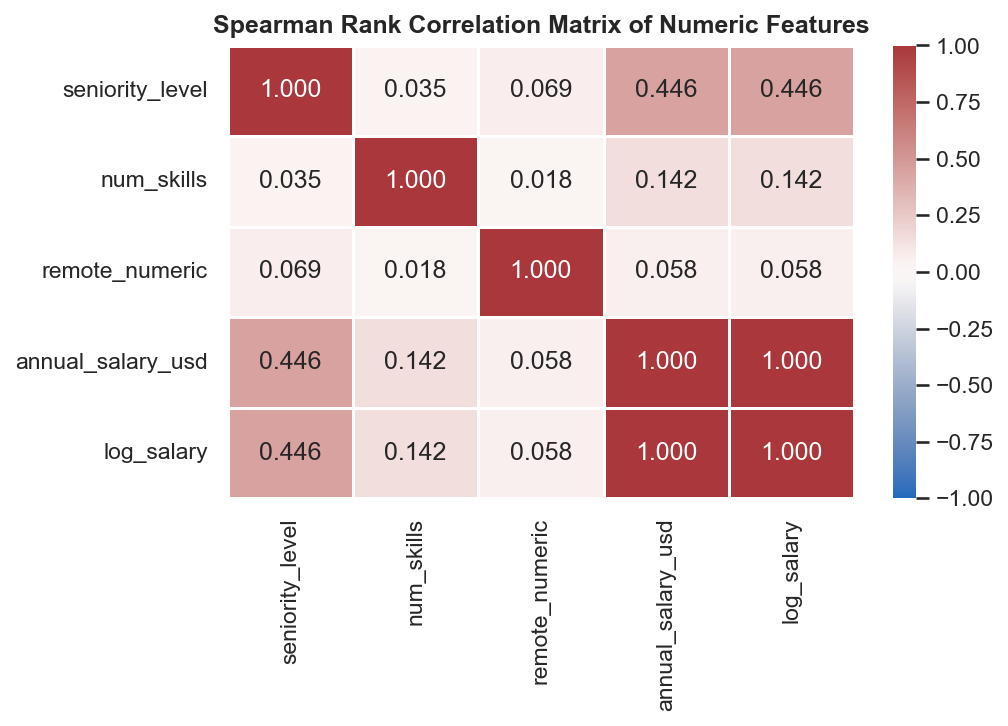

In [13]:
# Missingness Table
cols_check = ['job_id', 'title', 'company_name', 'department', 'city', 'country', 'is_remote', 'salary_midpoint', 'skills']
miss_data = []
for c in cols_check:
    c_corpus = df_corpus[c].isnull().sum() if c in df_corpus.columns else 0
    c_model = df_model[c].isnull().sum() if c in df_model.columns else 0
    miss_data.append({
        "Field": c,
        "Corpus_Missing": c_corpus,
        "Corpus_Rate": c_corpus / len(df_corpus),
        "Modeling_Missing": c_model,
        "Modeling_Rate": c_model / len(df_model)
    })

display(pd.DataFrame(miss_data).style.format({
    "Corpus_Missing": "{:,}",
    "Corpus_Rate": "{:.2%}",
    "Modeling_Missing": "{:,}",
    "Modeling_Rate": "{:.2%}"
}))

# Numeric correlation matrix
sen_map = {'Intern': 0, 'Junior / Entry': 1, 'Mid / Unspecified': 2, 'Senior': 3, 'Lead / Principal / Executive': 4}
df_model['seniority_level'] = df_model['seniority'].map(sen_map)
df_model['remote_numeric'] = df_model['is_remote'].astype(int)

num_cols = ['seniority_level', 'num_skills', 'remote_numeric', 'annual_salary_usd', 'log_salary']
corr_matrix = df_model[num_cols].corr(method='spearman')

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', vmin=-1, vmax=1, fmt='.3f', linewidths=0.5)
plt.title("Spearman Rank Correlation Matrix of Numeric Features", fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Synthesis & Research Questions Preparation

| Research Question | Phase 3 Status | Exploratory Evidence & Key Findings |
|---|---|---|
| **RQ1: Skills & Combinations vs. Salary** | **Partially Investigated** | Individual skill premiums identified: PyTorch (+22.3%), Deep Learning (+19.2%), TensorFlow (+17.0%), Scala (+16.3%), ML (+15.0%), Rust (+13.9%). Synergistic combinations discovered: `ML + Rust` ($222k), `ML + C++` ($221k), `Data Eng + Rust` ($220k). Causal claims avoided. |
| **RQ2: Skill-Based Archetypes** | **Prepared, Not Answered** | Jaccard co-occurrence matrix reveals distinct functional sub-graphs: (1) Cloud/DevOps (`aws`, `kubernetes`, `docker`, `ci-cd`, `terraform`), (2) Data/AI Stack (`python`, `sql`, `machine-learning`, `spark`, `airflow`), (3) Web/App Stack (`typescript`, `react`, `node.js`). Unsupervised clustering deferred to Phase 4. |
| **RQ3: Error across Archetypes** | **Not Yet Evaluated** | Baseline salary variance by role family ($H = 3,282.05$) and seniority ($H = 7,220.05$) established. Requires downstream regression models and archetype cluster assignments in Phases 4 & 5. |

---

### Phase 4 Handoff & Clustering Leakage Rule
1. **PCA Input:** `skill_matrix_technical.parquet` ($335,995 \times 82$ binary indicators, 94.88% sparse).
2. **Clustering Leakage Protocol:** In Phase 5 supervised modeling, PCA and K-Means feature extractors **must be fitted strictly on training partition folds** ($X_{\text{train}}$) and applied transformatively to test folds. Never fit cluster assignments globally on the modeling population prior to cross-validation splitting.

*Phase 3 Exploratory Data Analysis is complete. Ready for Phase 4.*
